# Superstore Sales Analysis

## Business Question
How can the business maximize revenue during peak season 
by focusing on the highest performing regions, categories, 
and customer segments?

## Dataset
- Source: Kaggle Superstore Sales Dataset
- File: train.csv
- Size: ~9,800 rows, 18 columns
- Period: 2015-2018
- Scope: US retail orders including sales, customers, 
  products, regions and shipping details

## Workflow
1. Setup & Imports
2. Load Data
3. First Look
4. Data Cleaning
5. Univariate Analysis
6. Bivariate Analysis
7. Business Question Analysis
8. Findings & Recommendations

## 1. Setup & Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Plot styling
plt.style.use('seaborn-v0_8')


## 2. Load Data

In [3]:
df = pd.read_csv('../data/raw/train.csv')

print(f"Dataset loaded successfully")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully
Shape: 9800 rows, 18 columns


## 3. First Look
### Checking the structure, data types, and a sample of the data

In [4]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [5]:
print(df.describe())

            Row ID   Postal Code         Sales
count  9800.000000   9789.000000   9800.000000
mean   4900.500000  55273.322403    230.769059
std    2829.160653  32041.223413    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%    4900.500000  58103.000000     54.490000
75%    7350.250000  90008.000000    210.605000
max    9800.000000  99301.000000  22638.480000


In [6]:
print(df.dtypes)

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object


### Findings from First Look
- Dataset has 9,800 rows and 18 columns
- Only 3 numeric columns: Row ID, Postal Code, Sales
- Remaining 15 columns are text/categorical
- Dates are stored as strings — need conversion
- Sales range from $0.44 to $22,638 — right skewed distribution

## 4. Data Cleaning

### Cleaning Steps:
1. Check for duplicates
2. Standardize column names
3. Convert date columns to datetime
4. Extract time features
5. Check for missing values and empty strings
6. Validate categorical columns for typos
7. Investigate outliers in Sales column
8. Drop unnecessary columns

In [7]:
### 4.1 Duplicate Check

# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check for duplicate Order IDs
print(f"Duplicate Order IDs: {df.duplicated(subset=['Order ID']).sum()}")

# Total unique orders
print(f"Unique Order IDs: {df['Order ID'].nunique()}")

Duplicate rows: 0
Duplicate Order IDs: 4878
Unique Order IDs: 4922


### 4.1 Duplicate Check — Findings
- No exact duplicate rows 
- Order ID appears multiple times by design — one row per product per order
- Table grain: one row = one product line within one order
- When counting orders always use nunique() on Order ID

In [8]:
### 4.2 Standardize Column Names

# Lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

print("New column names:")
print(df.columns.tolist())

New column names:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales']


### 4.2 Standardize Column Names — Findings
- All column names converted to lowercase with underscores
- Eliminates errors when referencing columns in code
- Example: 'Order ID' → 'order_id', 'Ship Date' → 'ship_date'

In [9]:
### 4.3 Data Type Conversion

# Convert date columns from string to datetime
df['order_date'] = pd.to_datetime(df['order_date'], format='%d/%m/%Y')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%d/%m/%Y')

# Convert postal code to string
df['postal_code'] = df['postal_code'].astype(str)

# Drop row_id — adds no analytical value
df = df.drop(columns=['row_id'])

# Verify
print("=== DTYPES AFTER CONVERSION ===")
print(df.dtypes)
print(f"\nColumns remaining: {len(df.columns)}")

=== DTYPES AFTER CONVERSION ===
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code                 str
region                      str
product_id                  str
category                    str
sub-category                str
product_name                str
sales                   float64
dtype: object

Columns remaining: 17


In [10]:
### 4.4 Missing Values & Empty Strings

# Check for nulls
print("=== NULL VALUES ===")
print(df.isnull().sum())

# Check for empty strings
print("\n=== EMPTY STRINGS ===")
for col in df.columns:
    empty = (df[col].astype(str).str.strip() == '').sum()
    if empty > 0:
        print(f"{col}: {empty} empty strings")
    
print("Empty string check complete")

=== NULL VALUES ===
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_id       0
customer_name     0
segment           0
country           0
city              0
state             0
postal_code      11
region            0
product_id        0
category          0
sub-category      0
product_name      0
sales             0
dtype: int64

=== EMPTY STRINGS ===
Empty string check complete


### 4.4 Missing Values — Findings
- Only 11 null values found in postal_code column
- No empty strings found across any column
- postal_code nulls left as-is — column not used in analysis
- Dataset is clean with no critical missing values 

In [11]:
### 4.5 Validate Categorical Columns

# Check unique values in all categorical columns
from IPython.display import display
pd.set_option('display.max_rows', None)

cat_cols = ['ship_mode', 'segment', 'country', 
            'region', 'category', 'sub-category']

for col in cat_cols:
    print(f"\n{col.upper()} ({df[col].nunique()} unique):")
    display(df[col].value_counts())


SHIP_MODE (4 unique):


ship_mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64


SEGMENT (3 unique):


segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64


COUNTRY (1 unique):


...

region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64


CATEGORY (3 unique):


category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64


SUB-CATEGORY (17 unique):


sub-category
Binders        1492
Paper          1338
Furnishings     931
Phones          876
Storage         832
Art             785
Accessories     756
Chairs          607
Appliances      459
Labels          357
Tables          314
Envelopes       248
Bookcases       226
Fasteners       214
Supplies        184
Machines        115
Copiers          66
Name: count, dtype: int64

In [12]:
# Drop country column - only one unique value, adds no analytical value
df = df.drop(columns=['country'])

print(f"Columns after dropping country: {len(df.columns)}")
print(df.columns.tolist())

Columns after dropping country: 16
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales']


### 4.5 Categorical Validation — Findings
- No typos or inconsistencies found in any categorical column 
- All categories are clean and consistent 
- country column dropped — only one unique value, adds no analytical value
- Dataset now has 16 columns

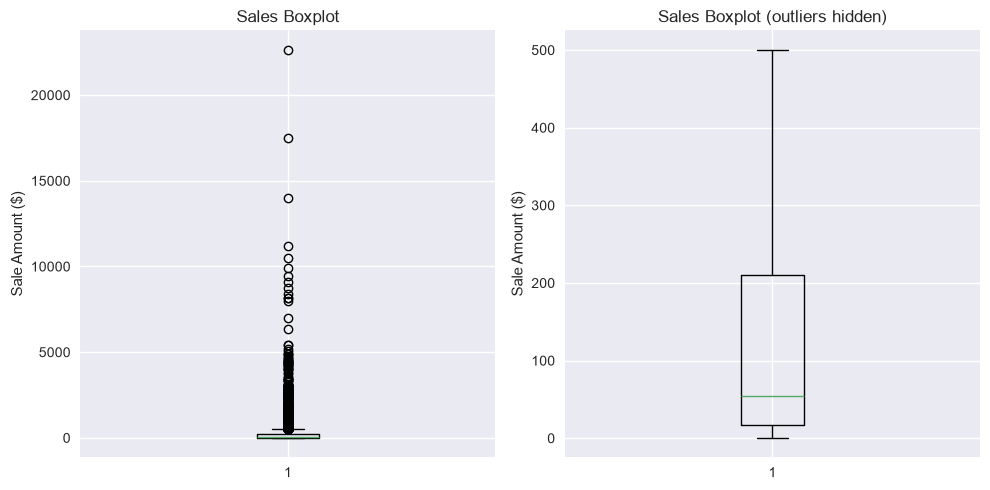

Q1: $17.25
Q3: $210.61
IQR: $193.36
Lower bound: $-272.79
Upper bound: $500.64
Number of outliers: 1145
Outlier % of dataset: 11.7%


In [13]:
### 4.6 Outlier Investigation
# Boxplot to visualize outliers in Sales
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df['sales'])
plt.title('Sales Boxplot')
plt.ylabel('Sale Amount ($)')

plt.subplot(1, 2, 2)
plt.boxplot(df['sales'], showfliers=False)
plt.title('Sales Boxplot (outliers hidden)')
plt.ylabel('Sale Amount ($)')

plt.tight_layout()
plt.savefig('../data/processed/sales_outliers.png', dpi=150)
plt.show()

# IQR method to identify outliers
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['sales'] < lower) | (df['sales'] > upper)]
print(f"Q1: ${Q1:.2f}")
print(f"Q3: ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"Lower bound: ${lower:.2f}")
print(f"Upper bound: ${upper:.2f}")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier % of dataset: {len(outliers)/len(df)*100:.1f}%")

### 4.6 Outlier Investigation — Findings
- IQR method identifies 1,145 orders (11.7%) as outliers
- All outliers are on the high end — orders above $500
- Lower bound is negative (-$272) — no outliers on low end
- Decision: KEEP outliers — these are legitimate high value orders
  (technology and furniture purchases naturally produce large orders)
- Median ($54) is more representative than mean ($230) for typical order value
- These high value orders will be analyzed separately as a key revenue driver

In [14]:
### 4.7 Shipping Days Validation

# Calculate shipping days
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

# Check for negative shipping days
negative = df[df['shipping_days'] < 0]
print(f"Negative shipping days: {len(negative)}")
print(f"\nShipping days summary:")
print(df['shipping_days'].describe())

Negative shipping days: 0

Shipping days summary:
count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: shipping_days, dtype: float64


### 4.7 Shipping Days Validation — Findings
- No negative shipping days found 
- Minimum: 0 days (same day delivery)
- Maximum: 7 days
- Average: ~4 days
- All values are realistic for retail shipping

### 4.8 Feature Engineering

In [15]:
# Extract time features from order_date
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter

print(f"Final columns: {df.columns.tolist()}")

Final columns: ['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'shipping_days', 'order_year', 'order_month', 'order_quarter']


### 4.8 Feature Engineering — Findings
- Added order_year, order_month, order_quarter from order_date
- Added shipping_days from ship_date - order_date
- Final dataset: 9,800 rows, 20 columns

### 4.9 Save Cleaned Dataset

In [16]:
# Save cleaned data to processed folder
df.to_csv('../data/processed/superstore_clean.csv', index=False)
print("Cleaned dataset saved to data/processed/superstore_clean.csv")
print(f"Shape: {df.shape}")

Cleaned dataset saved to data/processed/superstore_clean.csv
Shape: (9800, 20)


## 5. Univariate Analysis
### Analyzing each column individually to understand distributions and patterns

### 5.1 Sales Distribution

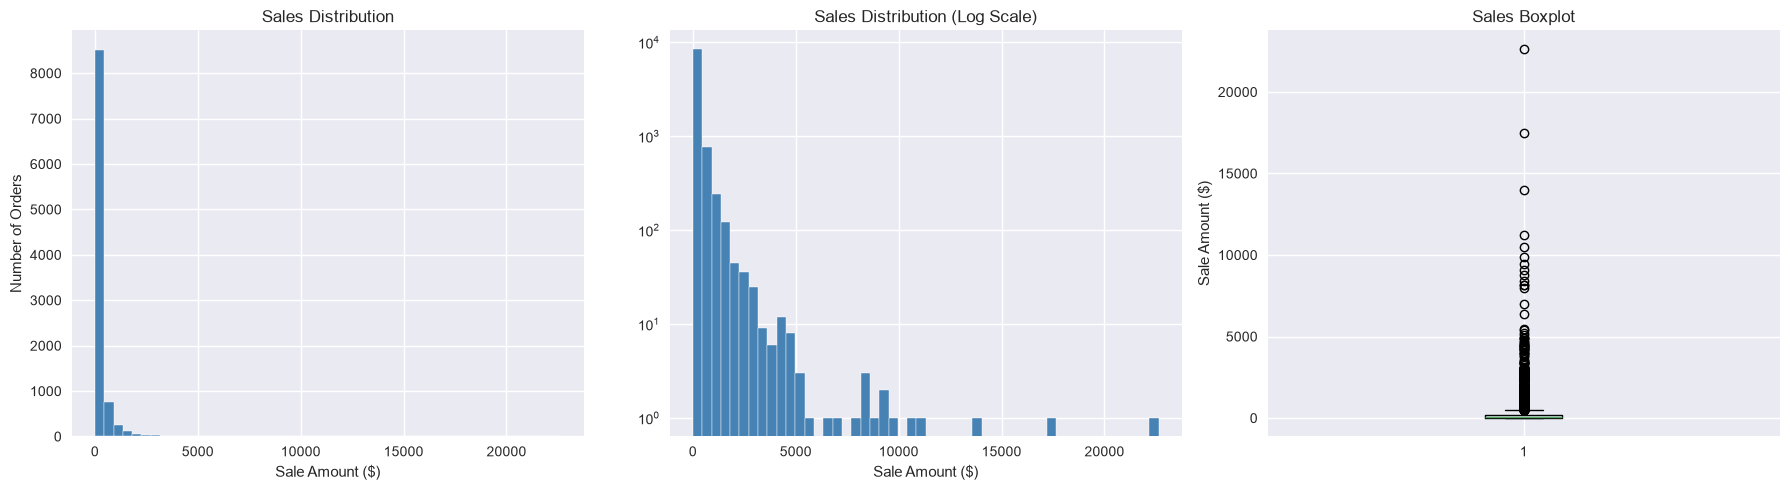

=== SALES SUMMARY ===
Mean:   $230.77
Median: $54.49
Std:    $626.65
Min:    $0.44
Max:    $22638.48


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sale Amount ($)')
axes[0].set_ylabel('Number of Orders')

# Log scale
axes[1].hist(df['sales'], bins=50, color='steelblue', edgecolor='white', log=True)
axes[1].set_title('Sales Distribution (Log Scale)')
axes[1].set_xlabel('Sale Amount ($)')

# Boxplot
axes[2].boxplot(df['sales'], showfliers=True)
axes[2].set_title('Sales Boxplot')
axes[2].set_ylabel('Sale Amount ($)')

plt.tight_layout()
plt.savefig('../data/processed/univariate_sales.png', dpi=150)
plt.show()

print("=== SALES SUMMARY ===")
print(f"Mean:   ${df['sales'].mean():.2f}")
print(f"Median: ${df['sales'].median():.2f}")
print(f"Std:    ${df['sales'].std():.2f}")
print(f"Min:    ${df['sales'].min():.2f}")
print(f"Max:    ${df['sales'].max():.2f}")

### 5.1 Sales Distribution — Findings
- Sales distribution is heavily right skewed
- Most orders (75%) fall below $210
- Mean ($230) is pulled upward by high value outliers — not representative
- Median ($54) is the more accurate measure of a typical order
- A small number of high value orders (>$500) drive a disproportionate 
  share of total revenue — the classic 80/20 pattern
- Business implication: protecting and growing the high value customer 
  segment is critical even though they represent a small % of order count

### 5.2 Categorical Columns Distribution

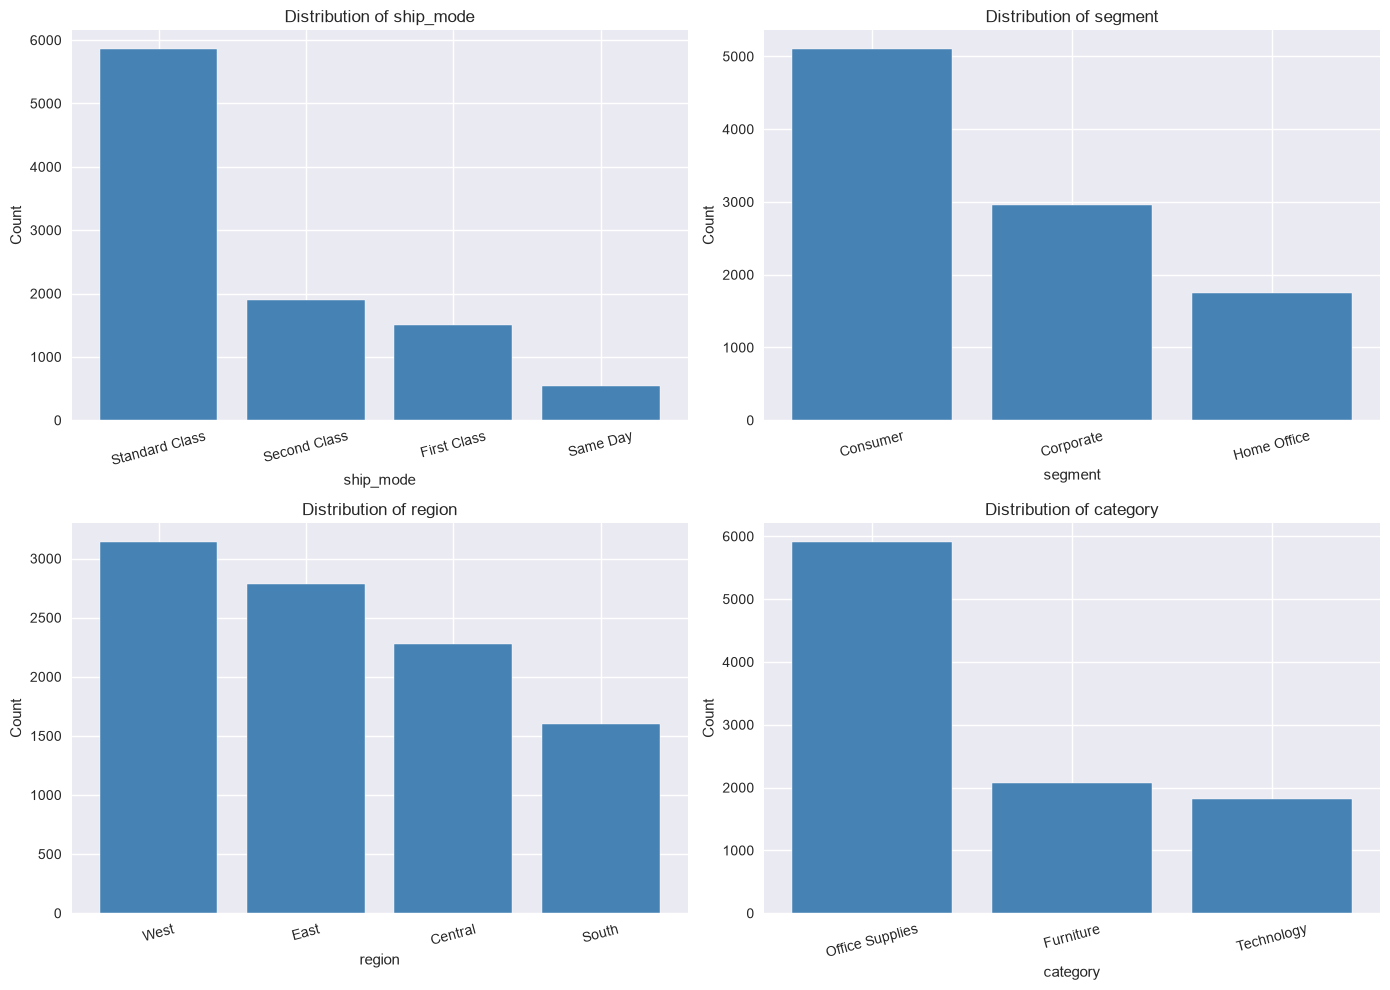

In [18]:
cat_cols = ['ship_mode', 'segment', 'region', 'category']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/processed/univariate_categorical.png', dpi=150)
plt.show()

### 5.2 Categorical Distribution — Findings
- Standard Class is the dominant shipping method (~60% of orders)
- Consumer segment has the most orders, nearly double Corporate
- West and East regions lead in order count, South is weakest
- Office Supplies leads in order count, Technology has the fewest orders

### 5.3 Shipping Days Distribution

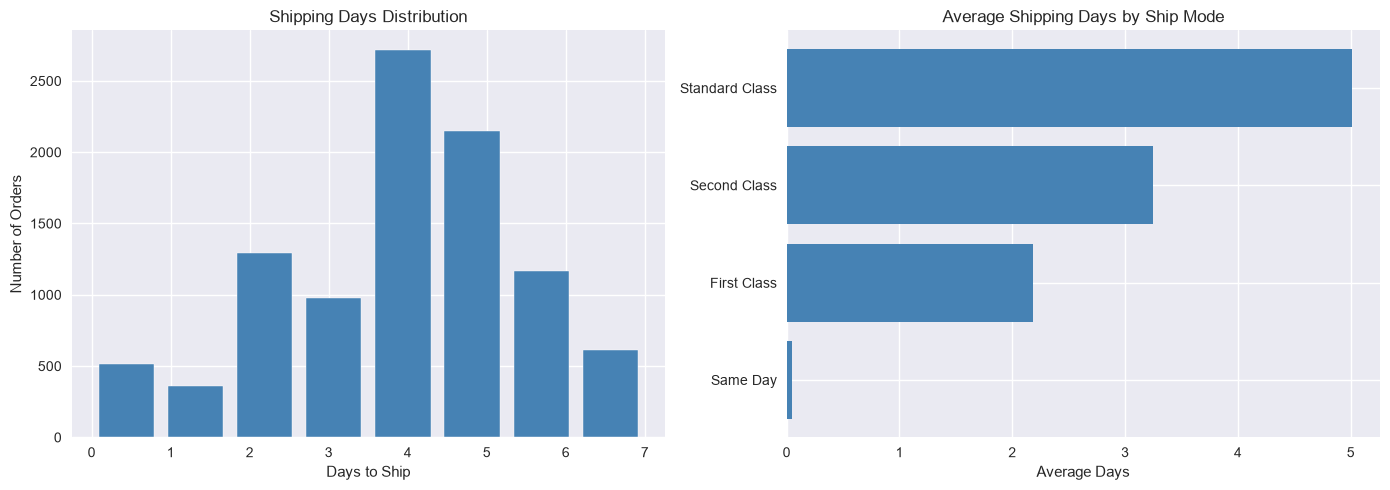

=== SHIPPING DAYS BY SHIP MODE ===
                 count      mean       std  min  25%  50%  75%  max
ship_mode                                                          
First Class     1501.0  2.179214  0.774076  1.0  2.0  2.0  3.0  4.0
Same Day         538.0  0.044610  0.206637  0.0  0.0  0.0  0.0  1.0
Second Class    1902.0  3.249211  1.188201  1.0  2.0  3.0  4.0  5.0
Standard Class  5859.0  5.008363  1.010578  3.0  4.0  5.0  6.0  7.0


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['shipping_days'], bins=8, color='steelblue', 
             edgecolor='white', rwidth=0.8)
axes[0].set_title('Shipping Days Distribution')
axes[0].set_xlabel('Days to Ship')
axes[0].set_ylabel('Number of Orders')

# By ship mode
ship_mode_days = df.groupby('ship_mode')['shipping_days'].mean().sort_values()
axes[1].barh(ship_mode_days.index, ship_mode_days.values, color='steelblue')
axes[1].set_title('Average Shipping Days by Ship Mode')
axes[1].set_xlabel('Average Days')

plt.tight_layout()
plt.savefig('../data/processed/univariate_shipping.png', dpi=150)
plt.show()

print("=== SHIPPING DAYS BY SHIP MODE ===")
print(df.groupby('ship_mode')['shipping_days'].describe())

### 5.3 Shipping Days — Findings
- Most orders take 4-5 days to ship — consistent with Standard Class 
  being the dominant shipping method
- Shipping days align perfectly with ship mode expectations
- No anomalies or impossible values found — data is consistent 
  and reliable 
- Business implication: customers choosing Standard Class are 
  comfortable waiting up to a week — price sensitivity over speed

## 6. Bivariate Analysis
### Exploring relationships between columns to find patterns and correlations

### 6.1 Sales by Category

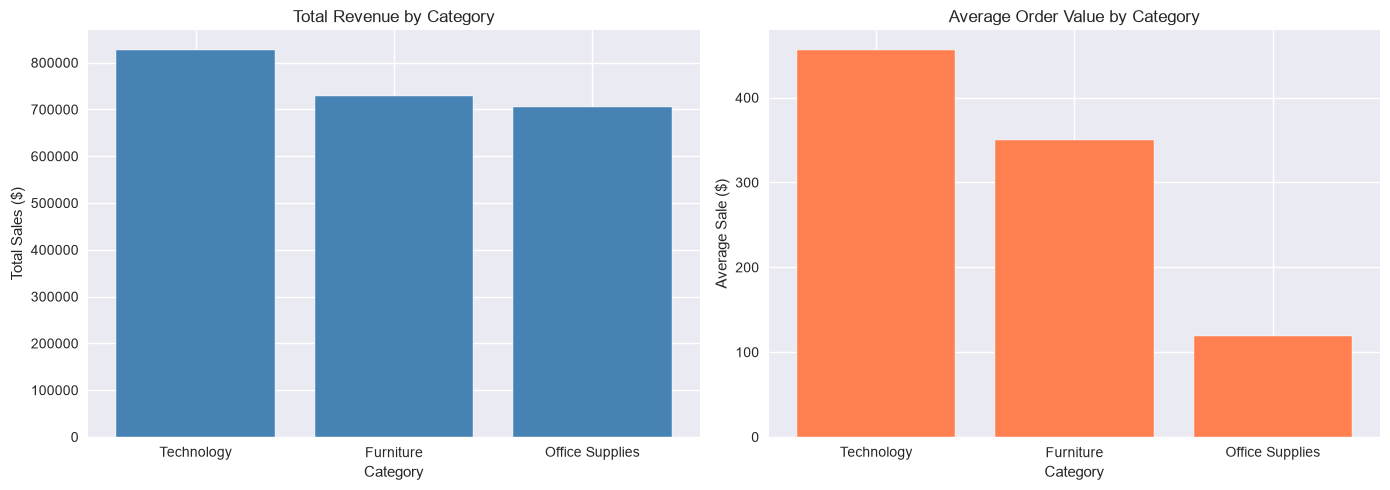

=== REVENUE BY CATEGORY ===
category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: sales, dtype: float64

=== AVERAGE ORDER VALUE BY CATEGORY ===
category
Technology         456.401474
Furniture          350.653790
Office Supplies    119.381001
Name: sales, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total revenue by category
cat_revenue = df.groupby('category')['sales'].sum().sort_values(ascending=False)
axes[0].bar(cat_revenue.index, cat_revenue.values, color='steelblue', edgecolor='white')
axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales ($)')

# Average order value by category
cat_avg = df.groupby('category')['sales'].mean().sort_values(ascending=False)
axes[1].bar(cat_avg.index, cat_avg.values, color='coral', edgecolor='white')
axes[1].set_title('Average Order Value by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Average Sale ($)')

plt.tight_layout()
plt.savefig('../data/processed/bivariate_category_sales.png', dpi=150)
plt.show()

print("=== REVENUE BY CATEGORY ===")
print(cat_revenue)
print("\n=== AVERAGE ORDER VALUE BY CATEGORY ===")
print(cat_avg)

### 6.1 Sales by Category — Findings
- Technology leads in both total revenue ($827k) and average order 
  value ($456) despite having the fewest orders
- Office Supplies has the highest order count but the lowest average 
  order value ($119) — needs ~4,000 more orders than Furniture 
  to achieve similar total revenue
- Furniture sits in the middle — decent average order value ($350) 
  but lower order volume
- Business implication: Technology delivers the highest revenue per 
  order — marketing investment in Technology yields the highest 
  return per dollar spent
- Office Supplies drives volume and customer engagement but is 
  operationally expensive to maintain at scale

### 6.2 Sales by Region

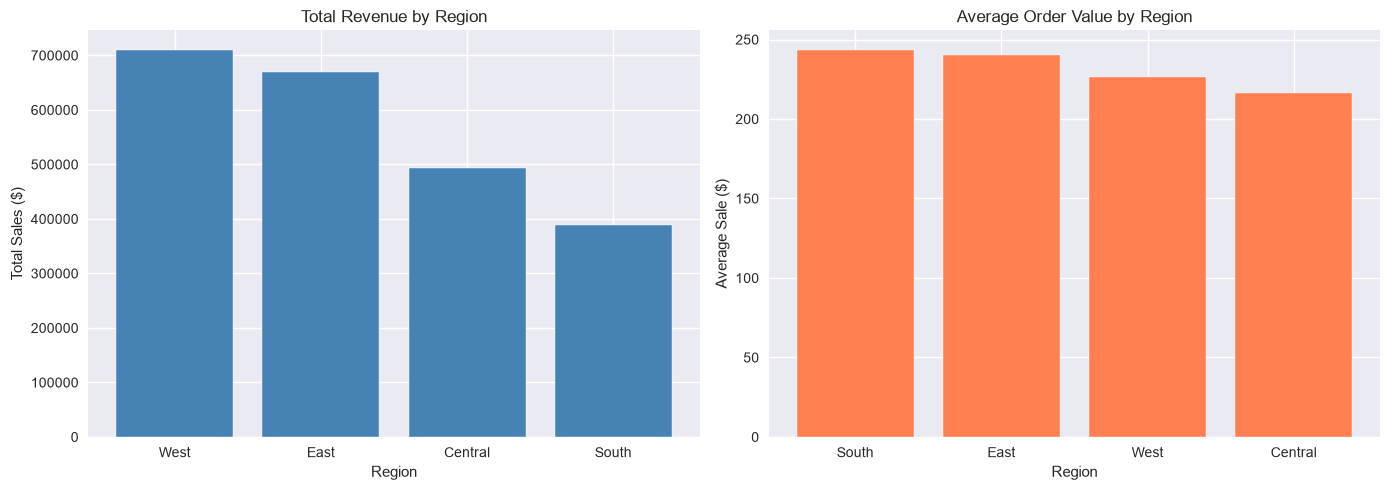

=== REVENUE BY REGION ===
region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: sales, dtype: float64

=== AVERAGE ORDER VALUE BY REGION ===
region
South      243.524067
East       240.401697
West       226.184613
Central    216.357889
Name: sales, dtype: float64


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total revenue by region
reg_revenue = df.groupby('region')['sales'].sum().sort_values(ascending=False)
axes[0].bar(reg_revenue.index, reg_revenue.values, color='steelblue', edgecolor='white')
axes[0].set_title('Total Revenue by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales ($)')

# Average order value by region
reg_avg = df.groupby('region')['sales'].mean().sort_values(ascending=False)
axes[1].bar(reg_avg.index, reg_avg.values, color='coral', edgecolor='white')
axes[1].set_title('Average Order Value by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Average Sale ($)')

plt.tight_layout()
plt.savefig('../data/processed/bivariate_region_sales.png', dpi=150)
plt.show()

print("=== REVENUE BY REGION ===")
print(reg_revenue)
print("\n=== AVERAGE ORDER VALUE BY REGION ===")
print(reg_avg)

### 6.2 Sales by Region — Findings
- West leads in total revenue ($710k) followed closely by East ($669k) 
  — Central and South lag significantly
- Average order value is surprisingly similar across all regions ($216-$243)
  meaning regional revenue differences are driven by ORDER VOLUME not 
  spending behavior
- South has the HIGHEST average order value ($243) yet the LOWEST 
  total revenue — South customers spend well when they buy, 
  the business simply hasn't reached enough of them
- Central and South underperformance is a customer acquisition problem, 
  not a spending problem
- Business implication: expanding customer reach in South and Central 
  would yield strong returns — the willingness to spend is already there

### 6.3 Sales by Segment

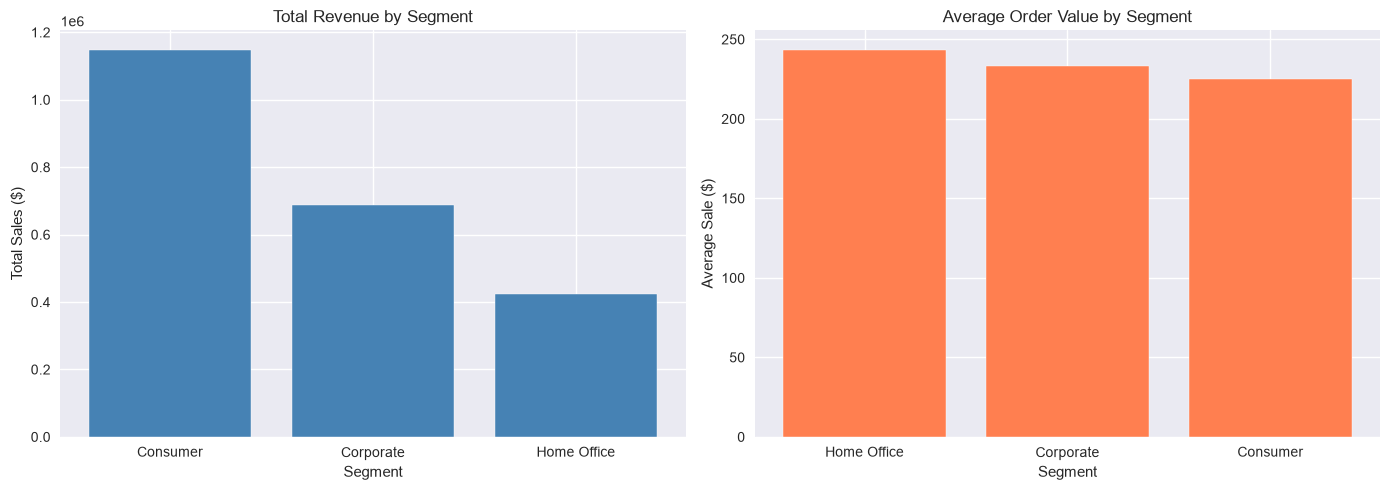

=== REVENUE BY SEGMENT ===
segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: sales, dtype: float64

=== AVERAGE ORDER VALUE BY SEGMENT ===
segment
Home Office    243.403309
Corporate      233.150720
Consumer       225.065777
Name: sales, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total revenue by segment
seg_revenue = df.groupby('segment')['sales'].sum().sort_values(ascending=False)
axes[0].bar(seg_revenue.index, seg_revenue.values, color='steelblue', edgecolor='white')
axes[0].set_title('Total Revenue by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Total Sales ($)')

# Average order value by segment
seg_avg = df.groupby('segment')['sales'].mean().sort_values(ascending=False)
axes[1].bar(seg_avg.index, seg_avg.values, color='coral', edgecolor='white')
axes[1].set_title('Average Order Value by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Average Sale ($)')

plt.tight_layout()
plt.savefig('../data/processed/bivariate_segment_sales.png', dpi=150)
plt.show()

print("=== REVENUE BY SEGMENT ===")
print(seg_revenue)
print("\n=== AVERAGE ORDER VALUE BY SEGMENT ===")
print(seg_avg)

### 6.3 Sales by Segment — Findings
- Consumer segment dominates total revenue ($1.14M) due to high 
  order volume despite having the lowest average order value ($225)
- Home Office has the highest average order value ($243) but the 
  lowest total revenue ($425k) — indicating a small but high-spending 
  customer base
- Corporate sits in the middle — decent order volume and average 
  order value ($233)
-  revenue differences are driven by  customer count, not spending behavior
- Business implication: acquiring more Corporate and Home Office 
  customers would meaningfully grow revenue — their willingness 
  to spend per order is already higher than Consumer

### 6.4 Sales Over Time

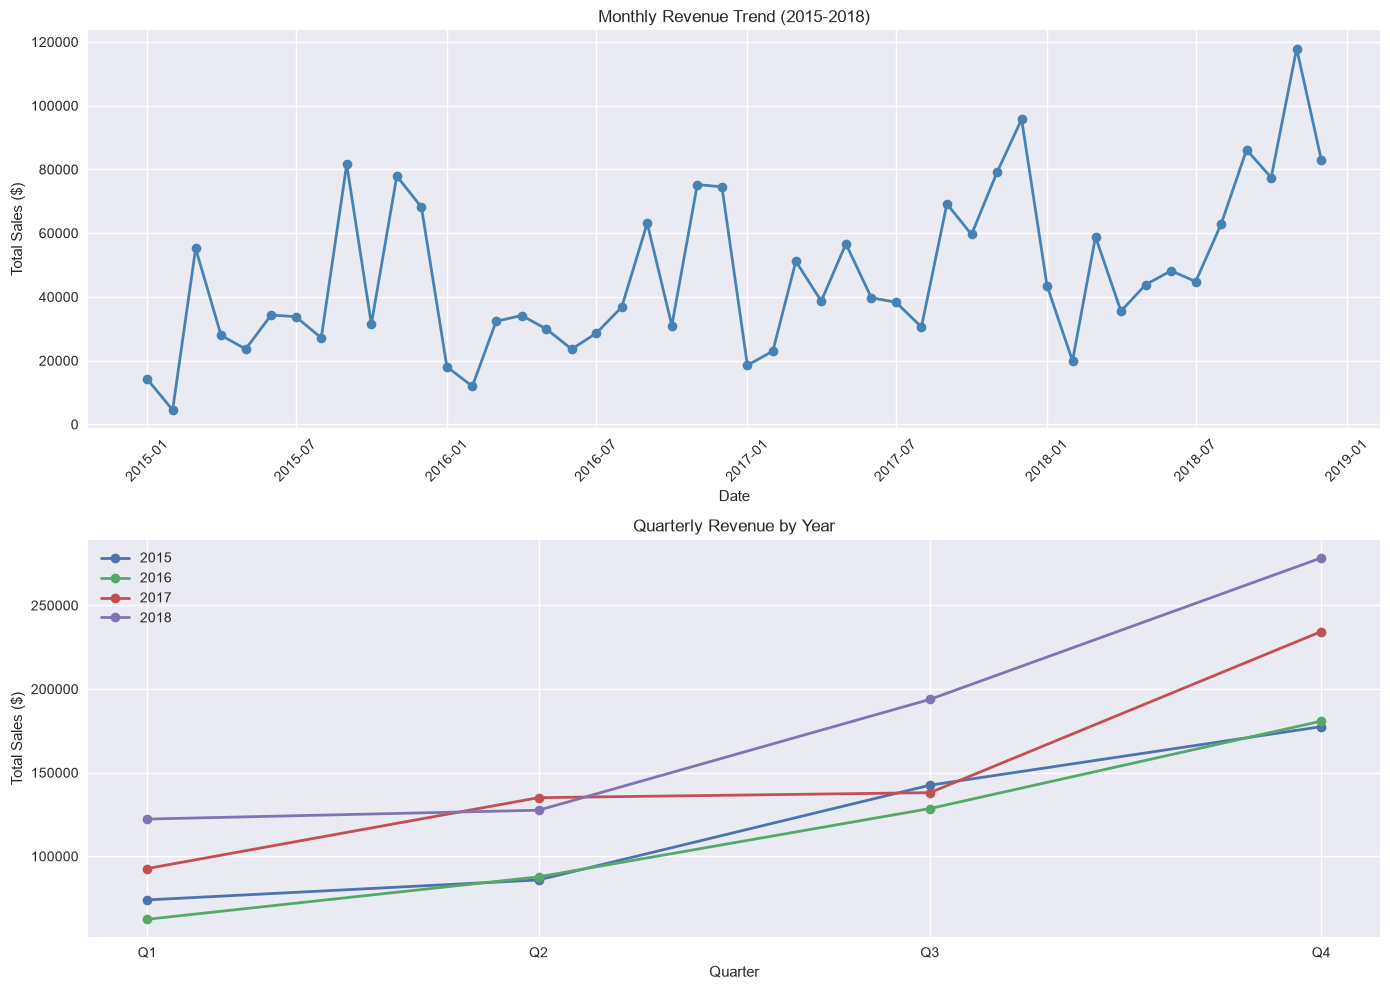

In [23]:
# Monthly revenue trend
monthly_revenue = df.groupby(['order_year', 'order_month'])['sales'].sum().reset_index()
monthly_revenue['date'] = pd.to_datetime({
    'year': monthly_revenue['order_year'],
    'month': monthly_revenue['order_month'],
    'day': 1
})
monthly_revenue = monthly_revenue.sort_values('date')

# Quarterly revenue trend
quarterly_revenue = df.groupby(['order_year', 'order_quarter'])['sales'].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Monthly
axes[0].plot(monthly_revenue['date'], monthly_revenue['sales'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Monthly Revenue Trend (2015-2018)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=45)

# Quarterly by year
for year in quarterly_revenue['order_year'].unique():
    data = quarterly_revenue[quarterly_revenue['order_year'] == year]
    axes[1].plot(data['order_quarter'], data['sales'],
                marker='o', label=str(year), linewidth=2)

axes[1].set_title('Quarterly Revenue by Year')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Total Sales ($)')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/bivariate_sales_time.png', dpi=150)
plt.show()

### 6.4 Sales Over Time — Findings
- Overall revenue is on a consistent upward trend from 2015 to 2018
- Strong seasonal pattern repeats every year without exception:
  - Q1: lowest point of the year — post-holiday slowdown
  - Q2 → Q3: steady growth
  - Q3 → Q4: sharp acceleration into peak season
  - Q4: highest revenue quarter every single year
- Each year's peak is higher than the previous year's peak — 
  the business is growing AND the seasonal effect is amplifying
- Each year's trough is higher than the previous year's trough — 
  even the slow periods are improving year over year
- Business implication: Q4 is predictable and plannable — the business 
  should prepare inventory, marketing, and staffing well in advance 
  of Q4 every year
- The consistent pattern across all 4 years makes this highly 
  reliable for forecasting

### 6.5 Category vs Segment — What does each segment buy?

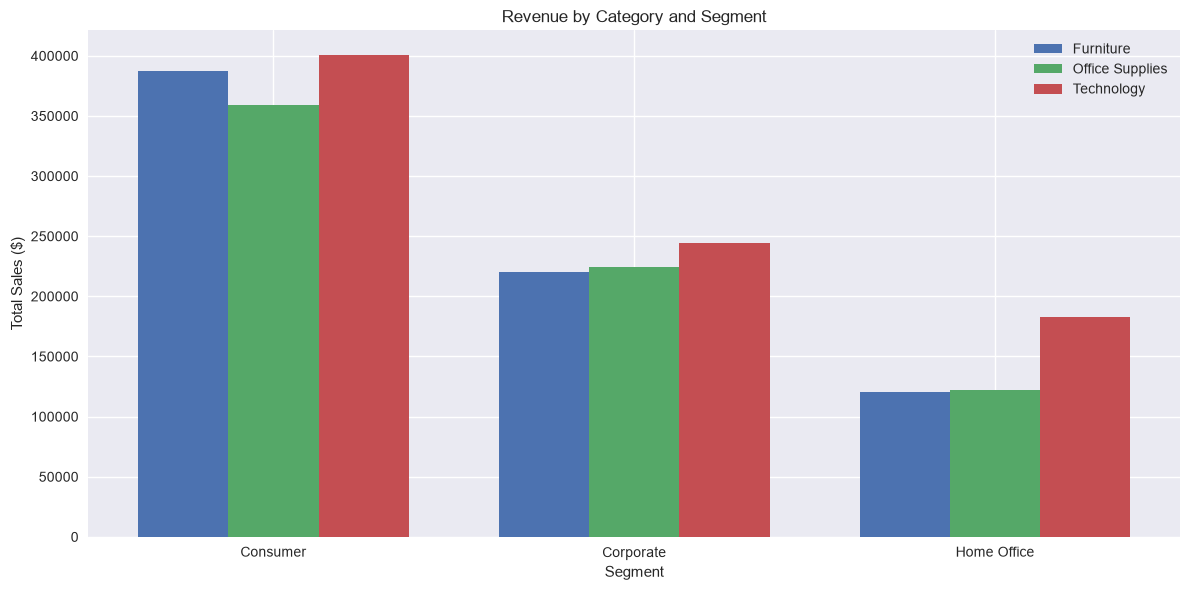

       segment         category        sales
2     Consumer       Technology  401011.6650
0     Consumer        Furniture  387696.2580
1     Consumer  Office Supplies  359352.6080
5    Corporate       Technology  244041.8370
4    Corporate  Office Supplies  224130.5360
3    Corporate        Furniture  220321.7018
8  Home Office       Technology  182402.3710
7  Home Office  Office Supplies  121939.1900
6  Home Office        Furniture  120640.6159


In [24]:
# Revenue by category and segment combined
cat_seg = df.groupby(['segment', 'category'])['sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

segments = cat_seg['segment'].unique()
categories = cat_seg['category'].unique()
x = range(len(segments))
width = 0.25

for i, category in enumerate(categories):
    data = cat_seg[cat_seg['category'] == category]
    values = [data[data['segment'] == seg]['sales'].values[0] 
              for seg in segments]
    ax.bar([xi + i*width for xi in x], values, width=width, label=category)

ax.set_title('Revenue by Category and Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Total Sales ($)')
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(segments)
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/bivariate_cat_segment.png', dpi=150)
plt.show()

print(cat_seg.sort_values('sales', ascending=False))

### 6.5 Category vs Segment — Findings
- Consumer segment dominates revenue across all three categories 
  — not just in total but in every individual category
- Technology is the top revenue category in every single segment:
  - Consumer + Technology: $401k (highest combination overall)
  - Corporate + Technology: $244k
  - Home Office + Technology: $182k
- Office Supplies is consistently second, Furniture third across 
  all segments
- Business implication: if the business had one Q4 marketing campaign,
  the highest ROI target would be Consumer segment + Technology products
  — that single combination generates more revenue than entire segments
- Corporate + Technology is the second priority — Corporate customers 
  spend reliably on Technology and have room to grow

## 7. Business Question Analysis

### "How can the business maximize revenue during peak season 
### by focusing on the highest performing regions, categories, 
### and customer segments?"

In [25]:
# All quarters in one groupby
quarterly = df.groupby(['order_year', 'order_quarter'])['sales'].sum().reset_index()
quarterly.columns = ['year', 'quarter', 'revenue']

# Calculate percentage of annual total
annual = df.groupby('order_year')['sales'].sum().reset_index()
annual.columns = ['year', 'total_revenue']

quarterly = quarterly.merge(annual, on='year')
quarterly['percentage'] = (quarterly['revenue'] / quarterly['total_revenue']) * 100

print(quarterly)

    year  quarter      revenue  total_revenue  percentage
0   2015        1   73931.3960    479856.2081   15.406990
1   2015        2   85874.0936    479856.2081   17.895797
2   2015        3  142522.6063    479856.2081   29.701107
3   2015        4  177528.1122    479856.2081   36.996106
4   2016        1   62357.6870    459436.0054   13.572660
5   2016        2   87713.3730    459436.0054   19.091532
6   2016        3  128560.2072    459436.0054   27.982179
7   2016        4  180804.7382    459436.0054   39.353628
8   2017        1   92686.3650    600192.5500   15.442772
9   2017        2  135061.1610    600192.5500   22.502972
10  2017        3  138056.3742    600192.5500   23.002014
11  2017        4  234388.6498    600192.5500   39.052242
12  2018        1  122260.8842    722052.0192   16.932421
13  2018        2  127558.6200    722052.0192   17.666126
14  2018        3  193815.8400    722052.0192   26.842365
15  2018        4  278416.6750    722052.0192   38.559088


### 7.1 Q4 Revenue Contribution — Findings
- Q4 consistently generates 37-39% of annual revenue every year 
  — nearly double the 25% that equal quarterly distribution would produce
- Quarter by quarter breakdown (avg across all years):
  - Q1: ~15% — slowest quarter, post-holiday drop
  - Q2: ~19% — modest recovery
  - Q3: ~27% — strong acceleration into peak season
  - Q4: ~38% — peak season, drives almost 2.5x more than Q1
- The pattern is remarkably stable across all 4 years — 
  this is not random, it is a predictable and plannable cycle
- In 2018 alone Q4 generated $278k — more than Q1 and Q2 combined
- Business implication: Q4 preparation is the single highest leverage 
  activity the business can do — inventory, staffing, and marketing 
  investment made before Q4 yields the highest return of any 
  time period in the year

### 7.2 Q4 Performance by Region
Which regions drive Q4 revenue and which are underperforming?

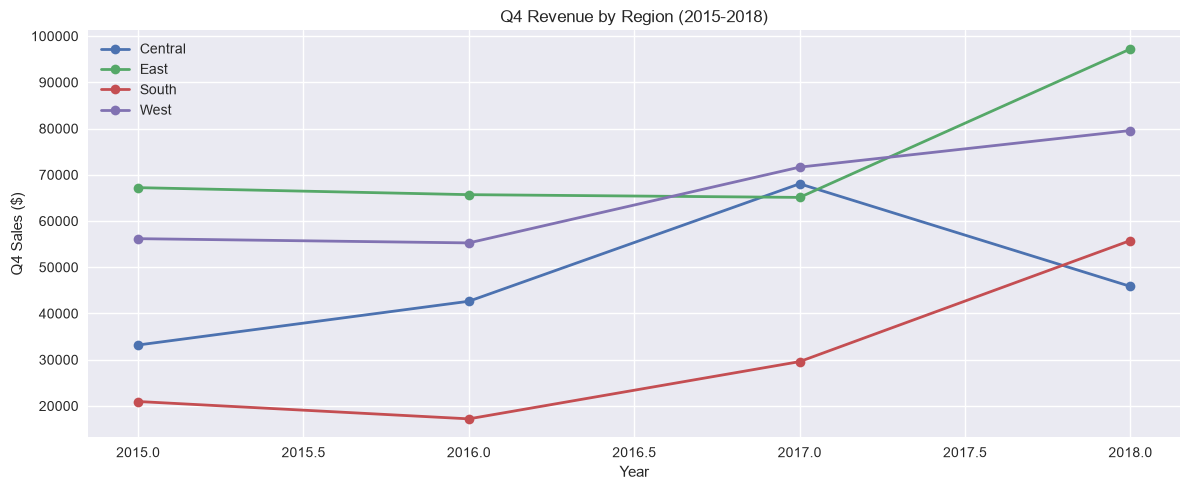

    year   region    q4_sales
0   2015  Central  33177.1872
1   2015     East  67215.9950
2   2015    South  20954.8000
3   2015     West  56180.1300
4   2016  Central  42641.1732
5   2016     East  65699.1980
6   2016    South  17201.8280
7   2016     West  55262.5390
8   2017  Central  68047.5978
9   2017     East  65105.6640
10  2017    South  29584.4910
11  2017     West  71650.8970
12  2018  Central  45850.8970
13  2018     East  97214.3650
14  2018    South  55778.0190
15  2018     West  79573.3940


In [26]:
q4 = df[df['order_quarter'] == 4]
q4_region = q4.groupby(['order_year', 'region'])['sales'].sum().reset_index()
q4_region.columns = ['year', 'region', 'q4_sales']

plt.figure(figsize=(12, 5))
for region in q4_region['region'].unique():
    data = q4_region[q4_region['region'] == region]
    plt.plot(data['year'], data['q4_sales'], 
             marker='o', label=region, linewidth=2)

plt.title('Q4 Revenue by Region (2015-2018)')
plt.xlabel('Year')
plt.ylabel('Q4 Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/q4_region.png', dpi=150)
plt.show()

print(q4_region)

### 7.2 Q4 Performance by Region — Findings
- East and West consistently dominate Q4 revenue across all years
- East showed explosive growth in 2018 — jumping from $65k to $97k, 
  the largest single year increase of any region — now the clear Q4 leader
- West grew steadily from $56k (2015) to $79k (2018) — reliable 
  and consistent performer
- Central is a red flag — grew strongly to $68k in 2017 then 
  dropped to $45k in 2018 — needs investigation, something changed
- South is the turnaround story — tripled from $17k (2016) to 
  $55k (2018) — momentum is building and should not be ignored
- Business recommendations for Q4 investment:
  - Double down on East — highest revenue and fastest growing
  - Maintain West — consistent and reliable
  - Investigate Central decline before investing further
  - Accelerate South — strong growth momentum, still underpenetrated

### 7.3 Q4 Performance by Category
Which categories drive Q4 revenue?

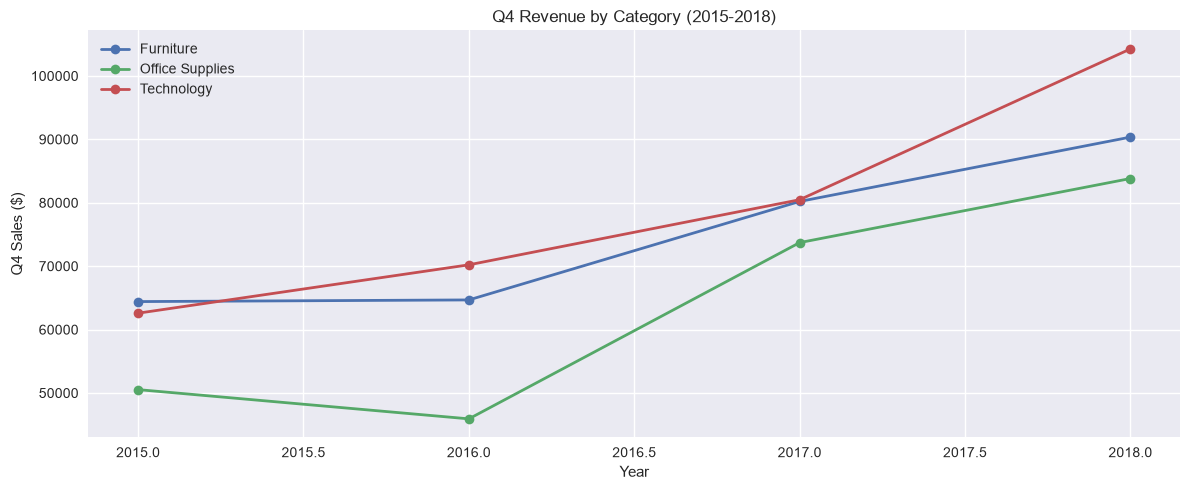

    year         category     q4_sales
0   2015        Furniture   64412.6302
1   2015  Office Supplies   50530.8160
2   2015       Technology   62584.6660
3   2016        Furniture   64674.2392
4   2016  Office Supplies   45919.9800
5   2016       Technology   70210.5190
6   2017        Furniture   80201.6028
7   2017  Office Supplies   73711.3960
8   2017       Technology   80475.6510
9   2018        Furniture   90348.2500
10  2018  Office Supplies   83818.7490
11  2018       Technology  104249.6760


In [27]:
q4 = df[df['order_quarter'] == 4]
q4_category = q4.groupby(['order_year', 'category'])['sales'].sum().reset_index()
q4_category.columns = ['year', 'category', 'q4_sales']

plt.figure(figsize=(12, 5))
for category in q4_category['category'].unique():
    data = q4_category[q4_category['category'] == category]
    plt.plot(data['year'], data['q4_sales'], 
             marker='o', label=category, linewidth=2)

plt.title('Q4 Revenue by Category (2015-2018)')
plt.xlabel('Year')
plt.ylabel('Q4 Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/q4_category.png', dpi=150)
plt.show()

print(q4_category)

### 7.3 Q4 Performance by Category — Findings
- All three categories show consistent Q4 growth every year — 
  confirming Q4 is a rising tide that lifts all categories
- Technology dominates Q4 revenue and is accelerating:
  - 2015: $62k → 2018: $104k — 66% growth over 4 years
  - In 2018 Technology outperformed Furniture by ~15% and 
    Office Supplies by ~24%
- Furniture is a steady Q4 performer — grew from $64k to $90k 
  but lacks the acceleration of the other two categories
- Office Supplies is the surprise growth story:
  - Nearly doubled from $45k (2016) to $83k (2018)
  - Fastest growth rate of any category in Q4
  - Likely driven by Corporate end-of-year budget spending
- Business recommendations:
  - Prioritize Technology inventory and promotions for Q4 — 
    highest revenue and still accelerating
  - Don't underestimate Office Supplies — its Q4 growth rate 
    suggests untapped Corporate demand
  - Furniture needs a Q4 strategy refresh — steady but falling 
    behind the other two categories

### 7.4 Q4 Performance by Segment
Which customer segments drive Q4 revenue?

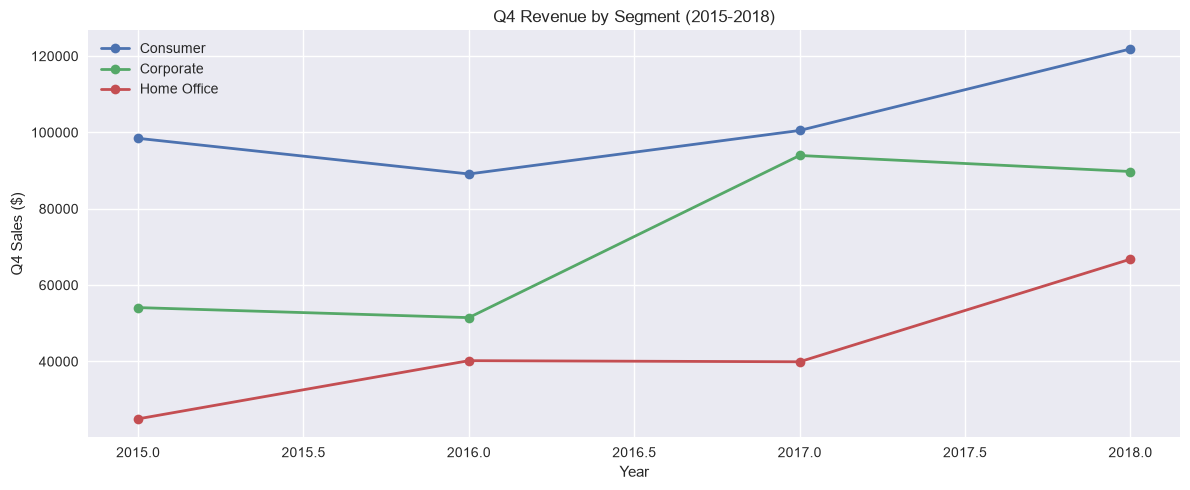

    year      segment     q4_sales
0   2015     Consumer   98454.6195
1   2015    Corporate   54111.4647
2   2015  Home Office   24962.0280
3   2016     Consumer   89114.5082
4   2016    Corporate   51482.7288
5   2016  Home Office   40207.5012
6   2017     Consumer  100512.2718
7   2017    Corporate   93959.4110
8   2017  Home Office   39916.9670
9   2018     Consumer  121865.4588
10  2018    Corporate   89759.5862
11  2018  Home Office   66791.6300


In [28]:
q4 = df[df['order_quarter'] == 4]
q4_segment = q4.groupby(['order_year', 'segment'])['sales'].sum().reset_index()
q4_segment.columns = ['year', 'segment', 'q4_sales']

plt.figure(figsize=(12, 5))
for segment in q4_segment['segment'].unique():
    data = q4_segment[q4_segment['segment'] == segment]
    plt.plot(data['year'], data['q4_sales'], 
             marker='o', label=segment, linewidth=2)

plt.title('Q4 Revenue by Segment (2015-2018)')
plt.xlabel('Year')
plt.ylabel('Q4 Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/q4_segment.png', dpi=150)
plt.show()

print(q4_segment)

### 7.4 Q4 Performance by Segment — Findings
- Consumer segment dominates Q4 revenue every year — grew from 
  $98k (2015) to $121k (2018), consistent and accelerating
- Corporate is a strong second but showed a concerning pattern:
  - Nearly caught Consumer in 2017 ($93k vs $100k)
  - Dropped back to $89k in 2018 while Consumer surged — 
    needs investigation, Corporate Q4 demand may be inconsistent
- Home Office is the smallest segment but growing steadily:
  - Grew from $24k (2015) to $66k (2018) — nearly tripled
  - Slowest in absolute terms but strong growth rate
- Business recommendations for Q4 by segment:
  - Consumer: maintain and grow — highest revenue, still accelerating,
    focus on Technology and holiday promotions
  - Corporate: investigate 2018 drop — if recoverable, Corporate 
    represents the biggest Q4 upside given its 2017 performance
  - Home Office: nurture the growth — small but tripling in 4 years 
    suggests an emerging customer base worth investing in early

### 7.5 The Best Q4 Combination
Which region + category + segment combination drives the most Q4 revenue?

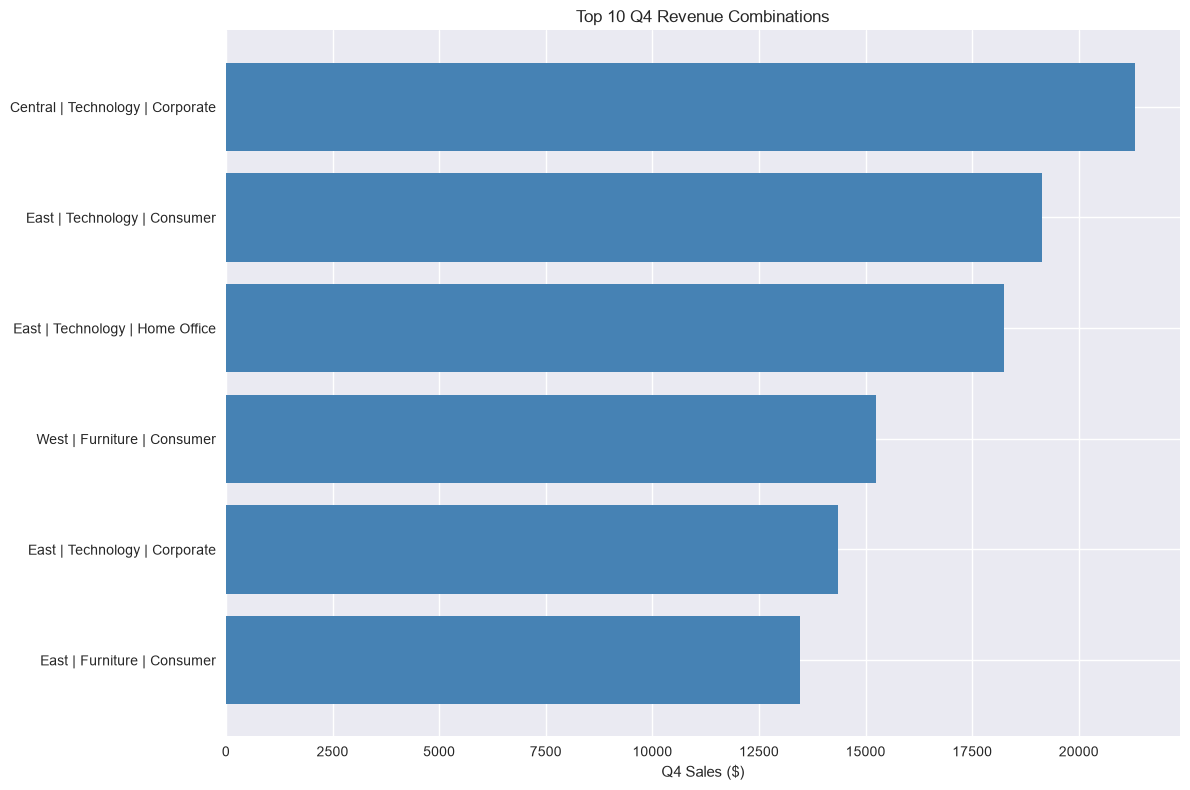

     order_year   region    category      segment       sales  \
78         2017  Central  Technology    Corporate  21308.3140   
15         2015     East  Technology     Consumer  19131.2260   
124        2018     East  Technology  Home Office  18235.7060   
122        2018     East  Technology     Consumer  17839.7440   
51         2016     East  Technology     Consumer  16046.1100   
98         2017     West   Furniture     Consumer  15234.0100   
134        2018     West   Furniture     Consumer  14929.1130   
123        2018     East  Technology    Corporate  14345.8070   
27         2015     West   Furniture     Consumer  14271.0805   
80         2017     East   Furniture     Consumer  13466.5140   

                                label  
78   Central | Technology | Corporate  
15       East | Technology | Consumer  
124   East | Technology | Home Office  
122      East | Technology | Consumer  
51       East | Technology | Consumer  
98        West | Furniture | Consumer  
134 

In [29]:
q4 = df[df['order_quarter'] == 4]
q4_combinations = q4.groupby(['order_year','region','category','segment'])['sales'].sum().reset_index()
q4_combinations = q4_combinations.sort_values('sales', ascending=False)
top10 = q4_combinations.head(10)
top10['label'] = top10['region'] + ' | ' + top10['category'] + ' | ' + top10['segment']

plt.figure(figsize=(12, 8))
plt.barh(top10['label'], top10['sales'], color='steelblue')
plt.title('Top 10 Q4 Revenue Combinations')
plt.xlabel('Q4 Sales ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/q4_combinations.png', dpi=150)
plt.show()
print(top10)

### 7.5 The Best Q4 Combination — Findings
- Technology is the dominant Q4 category — appears in 7 out of 
  the top 10 revenue combinations, confirming it as the 
  primary Q4 revenue driver
- Surprising #1 combination: Central | Technology | Corporate ($21k) —
  despite Central's overall underperformance, a small number of large 
  Corporate Technology orders drove exceptional Q4 revenue in 2017
  This did not repeat in 2018 — suggesting inconsistent Corporate 
  relationships in Central that need to be strengthened
- Most consistent combination: East | Technology | Consumer —
  appears multiple times across different years, reliable and growing
- Strong secondary pattern: West | Furniture | Consumer —
  appears 3 times in top 10, a dependable Q4 revenue stream 
  that shouldn't be overlooked
- Business recommendations for Q4 strategy:
  - Primary focus: East region + Technology + Consumer segment
    — most consistent, highest volume, still growing
  - High upside target: Central + Technology + Corporate 
    — proven $21k single quarter potential, needs relationship 
    investment to make it repeatable
  - Secondary focus: West + Furniture + Consumer 
    — reliable performer, lower ceiling but consistent returns

### Executive Summary

Analysis of 9,800 retail orders from 2015-2018 reveals a highly 
predictable revenue pattern with clear opportunities for growth.

**Key Finding:** Q4 consistently generates 38-39% of annual revenue 
every year — nearly double what any other quarter produces. This is 
not a coincidence, it is a reliable and plannable business cycle.

**Where the money comes from:** The East region leads Q4 performance 
and is accelerating — growing from $67k to $97k in Q4 alone. The 
Consumer segment drives the most volume while Technology is the 
highest revenue category, outperforming Furniture by 15% and Office 
Supplies by 24% in Q4 2018.

**The biggest opportunity:** South region has tripled its Q4 revenue 
from $17k (2016) to $55k (2018) — customers there spend just as much 
per order as other regions, the business simply hasn't reached enough 
of them yet. Targeted expansion into South before Q4 represents the 
highest growth opportunity available.

**The risk to monitor:** Central region showed a concerning drop in 
2018 after strong growth in 2017 — driven by inconsistent Corporate 
Technology orders. Strengthening Corporate relationships in Central 
could recover significant Q4 revenue.

**Recommended Q4 Strategy:**
1. Double down on East + Technology + Consumer — most consistent, 
   highest revenue combination
2. Expand reach in South — willingness to spend is proven, 
   customer base needs to grow
3. Investigate and recover Central Corporate Technology orders
4. Accelerate Office Supplies marketing to Corporate segment — 
   fastest growing Q4 category with clear Corporate demand signal